<a href="https://colab.research.google.com/github/Y-Awara/Team-UNO-acl/blob/main/draft_lab_3_manual_in_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Lab 3 Manual: Basics of Neural Networks with Tensorflow*

# **Libraries import and Data Cleaning**

**pandas:** the first library we learned, used for loading and handling datasets.

**numpy:** helps with math operations and working with arrays.

**tensorflow / keras:** used to build and train our neural network model.

**train_test_split:** splits the data into training and testing sets.

**StandardScaler:** prepares the data by scaling the features for better model performance.

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import Sequential, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.metrics import Precision, Recall


Next step is to load and prepare the data. You can refer to Lab Manual 1 for more information about Data Cleaning.

In [ ]:
df = pd.read_csv('train.csv')
# Basic cleaning
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
# Drop irrelevant columns
df = df.drop(columns=['Cabin', 'Name', 'Ticket'])


Let's take a look at the data after applying the preprocessing techniques

In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,False,True
1,2,1,1,1,38.0,1,0,71.2833,False,False
2,3,1,3,1,26.0,0,0,7.9250,False,True
3,4,1,1,1,35.0,1,0,53.1000,False,True
4,5,0,3,0,35.0,0,0,8.0500,False,True
5,6,0,3,0,28.0,0,0,8.4583,True,False
6,7,0,1,0,54.0,0,0,51.8625,False,True
7,8,0,3,0,2.0,3,1,21.0750,False,True
8,9,1,3,1,27.0,0,2,11.1333,False,True
9,10,1,2,1,14.0,1,0,30.0708,False,False


# **Defining Features and Target**
Before training a neural network model, we need to extract the features and the target (ground truth) from the dataset, depending on the task we want the model to learn.

**Features (X):** We select the columns Pclass, Sex, Age, Fare, SibSp, and Parch from the dataset. These variables will be used as inputs to the model.

**Target (y):** We choose the Survived column as the target variable, which represents the outcome we want the model to predict.

In [ ]:
# Feature and target
X = df[['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch']]
y = df['Survived']

In [ ]:
# Show the first 5 rows of features
print("Features (X):")
print(X.head())

# Show the first 5 rows of target values
print("\nTarget (y):")
print(y.head())

#Show the dimensions of both the Features and Targets dataframes
print("X and y dimensions:",X.shape,y.shape)

Features (X):
   Pclass  Sex   Age     Fare  SibSp  Parch
0       3    0  22.0   7.2500      1      0
1       1    1  38.0  71.2833      1      0
2       3    1  26.0   7.9250      0      0
3       1    1  35.0  53.1000      1      0
4       3    0  35.0   8.0500      0      0

Target (y):
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64
X and y dimensions: (891, 6) (891,)


# **Features Scaling**

We usually scale features before training machine learning models because raw features can have very different ranges and units, which may cause problems.

For example, in the Titanic dataset:

* Age ranges from about 0.1–80 years

* Fare ranges from about 20–500 dollars

Without scaling, algorithms that rely on distances or weights may treat Fare as more important than Age simply because the numbers are larger.

Standardization solves this by transforming each feature. We don't need to do that with the target labels, only the features.

In [ ]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Print first 5 rows of scaled features
print("Scaled Features (first 5 rows):")
print(X_scaled[:5])

print("Shape of 1 row:")
print(X_scaled[0].shape)

Scaled Features (first 5 rows):
[[ 0.82737724 -0.73769513 -0.56573646 -0.50244517  0.43279337 -0.47367361]
 [-1.56610693  1.35557354  0.66386103  0.78684529  0.43279337 -0.47367361]
 [ 0.82737724  1.35557354 -0.25833709 -0.48885426 -0.4745452  -0.47367361]
 [-1.56610693  1.35557354  0.4333115   0.42073024  0.43279337 -0.47367361]
 [ 0.82737724 -0.73769513  0.4333115  -0.48633742 -0.4745452  -0.47367361]]
Shape of 1 row:
(6,)


In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
#Explore the size and dimension of the train and test data after splitting:
print("Train data shape:",X_train.shape, "Train Label shape", y_train.shape)
print("Test data shape:",X_test.shape, "Test Label shape", y_test.shape)

Train data shape: (712, 6) Train Label shape (712,)
Test data shape: (179, 6) Test Label shape (179,)


# **Build a Feedforward Neural Network model**

**Input Layer:** Input(shape=(X_train.shape[1],)) creates the input layer with one neuron for each feature in the training data.

**First Hidden Layer:** A dense (fully connected) layer with 16 neurons. Each neuron learns from all the inputs of the previous layer.

**ReLU activation:** Outputs the input value if it’s positive, or 0 if it’s negative.

**Fully Connected Network:** Every neuron in one layer connects to all neurons in the next, each with its own weight, enabling the model to learn complex feature relationships.

In [ ]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
    ])

model.summary() displays a layer-by-layer summary of the neural network, including the number of parameters and how data flows through the model.

From the model's summary, we can see that the model parameters, it has a total of 257 parameters, all of which are trainable, meaning they will be updated during training. There are no non-trainable parameters, so every weight and bias in the network is being learned from the data.

In [ ]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

[Extra] If you are curious how our model reached 257 parameters, here's a breakdown:
| Connection                   | Weights Calculation | Biases | Total Params |
| ---------------------------- | ------------------- | ------ | ------------ |
| Input (6) → Dense(16, ReLU)  | (6 * 16 = 96)  | 16     | 112          |
| Dense(16) → Dense(8, ReLU)   | (16 * 8 = 128) | 8      | 136          |
| Dense(8) → Dense(1, Sigmoid) | (8 * 1 = 8)    | 1      | 9            |
| **Total**                    | —                   | —      | **257**      |



# **Compiling the Model**

Before training, we need to compile the model by specifying how it will learn:

Optimizer = 'adam': An efficient variant of gradient descent that adapts the learning rate during training.

Loss = 'binary_crossentropy': We chose this because our Titanic task has only two possible outputs, either **survived** or **not survived**. This loss function is designed for binary classification problems.

Accuracy, Precision, and Recall: are evaluation metrics that track how often the model’s predictions match the true labels, giving an easy-to-understand measure of performance.

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy',
                       Precision(name='precision'),
                       Recall(name='recall')])

# **Train the Neural Network Model**

**Validation Split:** Part of the training data is set aside (e.g., 80% train, 20% val) to monitor learning.

**Epoch:** One full pass through training data. More epochs help learning, but too many → overfitting.

**Loss** measures how far predictions are from true labels. We want this value to be as small as possible, ideally approaching 0.

**Accuracy** is the percentage of correct predictions. Values range from 0 to 1 (or 0% to 100%), and higher is better.

Same for both **precision** and **recall.** Values range from 0 to 1 (or 0% to 100%), and higher is better.

In [ ]:
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=1)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4152 - loss: 0.6926 - precision: 0.3744 - recall: 0.7730 - val_accuracy: 0.5455 - val_loss: 0.6734 - val_precision: 0.4194 - val_recall: 0.7800
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5829 - loss: 0.6714 - precision: 0.4562 - recall: 0.6678 - val_accuracy: 0.6294 - val_loss: 0.6568 - val_precision: 0.4800 - val_recall: 0.7200
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6635 - loss: 0.6527 - precision: 0.5738 - recall: 0.6673 - val_accuracy: 0.6713 - val_loss: 0.6440 - val_precision: 0.5224 - val_recall: 0.7000
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7103 - loss: 0.6396 - precision: 0.5986 - recall: 0.6558 - val_accuracy: 0.7552 - val_loss: 0.6304 - val_precision: 0.6364 - val_recall: 0.7000
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7609 - loss: 0.6186 - precision: 0.7081 - recall: 0.6550 - val_accuracy: 0.7832 - val_loss: 0.6149 - va

To avoid overfitting when training with many epochs, we use **early stopping**, which automatically stops training once the validation performance stops improving.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=50,
                    validation_split=0.2,
                    verbose=1,
                    callbacks=[early_stop])

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8147 - loss: 0.4484 - precision: 0.8318 - recall: 0.6774 - val_accuracy: 0.8112 - val_loss: 0.4147 - val_precision: 0.7255 - val_recall: 0.7400
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8127 - loss: 0.4462 - precision: 0.8224 - recall: 0.6493 - val_accuracy: 0.8182 - val_loss: 0.4130 - val_precision: 0.7400 - val_recall: 0.7400
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8180 - loss: 0.4285 - precision: 0.7921 - recall: 0.6954 - val_accuracy: 0.8182 - val_loss: 0.4118 - val_precision: 0.7400 - val_recall: 0.7400
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8200 - loss: 0.4417 - precision: 0.8062 - recall: 0.7046 - val_accuracy: 0.8182 - val_loss: 0.4113 - val_precision: 0.7400 - val_recall: 0.7400
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8244 - loss: 0.4188 - precision: 0.8170 - recall: 0.7228 - val_accuracy: 0.8182 - val_loss: 0.4121 - va

Rather than feeding the entire dataset through the network in a single step, the training data is divided into smaller subsets called **batches**. The model processes one batch at a time and updates its weights after each batch

In [ ]:
history2 = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8070 - loss: 0.4403 - precision: 0.7800 - recall: 0.6485 - val_accuracy: 0.8182 - val_loss: 0.4119 - val_precision: 0.7400 - val_recall: 0.7400
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8311 - loss: 0.4135 - precision: 0.8351 - recall: 0.6565 - val_accuracy: 0.8182 - val_loss: 0.4121 - val_precision: 0.7400 - val_recall: 0.7400
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8414 - loss: 0.3979 - precision: 0.8547 - recall: 0.7065 - val_accuracy: 0.8182 - val_loss: 0.4118 - val_precision: 0.7400 - val_recall: 0.7400
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7940 - loss: 0.4557 - precision: 0.7613 - recall: 0.6836 - val_accuracy: 0.8182 - val_loss: 0.4111 - val_precision: 0.7400 - val_recall: 0.7400
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8185 - loss: 0.4185 - precision: 0.7862 - recall: 0.7162 - val_accuracy: 0.8182 - val_loss: 0.4103 -

**Epochs**

One epoch = full pass through training data (all batches).

Too few: underfitting (model hasn’t learned enough).

Too many: overfitting + wasted compute.

Recommendation: start with moderate epochs (e.g., 30–100) and use early stopping.

**Batch Size**

Definition: number of samples before a weight update.

Small (16–32): more updates, better generalization, slower per epoch.

Large (128–256): fewer updates, faster per epoch, higher memory use, risk of weaker generalization.

Common defaults: 32 or 64.

# **Visualize the training progress.**

In [ ]:
import matplotlib.pyplot as plt

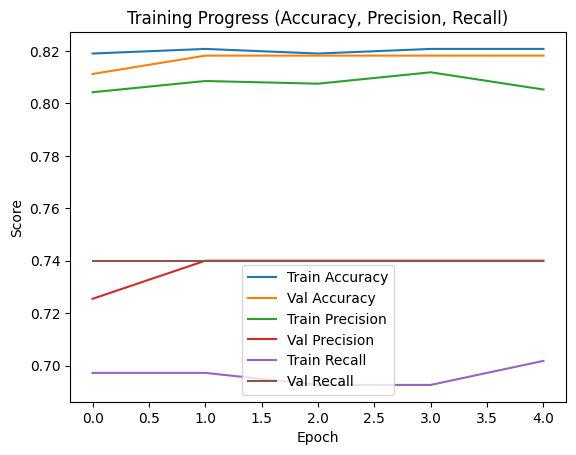

In [ ]:
# Plot accuracy, precision, and recall from training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')

plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')

plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Training Progress (Accuracy, Precision, Recall)')
plt.legend()
plt.show()


# **Evaluate on the test set.**

In [ ]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

Test Loss: 0.42293450236320496
Test Accuracy: 0.8212290406227112
Test Precision: 0.8181818127632141
Test Recall: 0.7297297120094299


# Task
Build and train two different neural network models using TensorFlow to predict survival. Evaluate both models, plot their training accuracy curves for comparison, and report their final test accuracies.

In [ ]:
# model with tanh activation fnc
model1 = Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(16, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy',
                        Precision(name='precision'),
                        Recall(name='recall')])

# Train the first model
history1 = model1.fit(X_train, y_train, epochs=30, validation_split=0.2, verbose=1)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7065 - loss: 0.5991 - precision: 0.6318 - recall: 0.6398 - val_accuracy: 0.8182 - val_loss: 0.4581 - val_precision: 0.7143 - val_recall: 0.8000
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7974 - loss: 0.4791 - precision: 0.7647 - recall: 0.7206 - val_accuracy: 0.8182 - val_loss: 0.4223 - val_precision: 0.7222 - val_recall: 0.7800
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7947 - loss: 0.4697 - precision: 0.7656 - recall: 0.7069 - val_accuracy: 0.7832 - val_loss: 0.4248 - val_precision: 0.6667 - val_recall: 0.7600
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8222 - loss: 0.4207 - precision: 0.7697 - recall: 0.7030 - val_accuracy: 0.8182 - val_loss: 0.4234 - val_precision: 0.7400 - val_recall: 0.7400
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8036 - loss: 0.4375 - precision: 0.7577 - recall: 0.6736 - val_accuracy: 0.7972 - val_loss: 0.4242 - v

## Evaluate model 1

### Subtask:
Evaluate the first model on the test set and report its performance.


**Reasoning**:
Evaluate the first model on the test set and print the evaluation metrics.



In [ ]:
test_loss1, test_accuracy1, test_precision1, test_recall1 = model1.evaluate(X_test, y_test, verbose=0)

print("Model 1 Test Loss:", test_loss1)
print("Model 1 Test Accuracy:", test_accuracy1)
print("Model 1 Test Precision:", test_precision1)
print("Model 1 Test Recall:", test_recall1)

model1.summary()

Model 1 Test Loss: 0.419551819562912
Model 1 Test Accuracy: 0.8156424760818481
Model 1 Test Precision: 0.8059701323509216
Model 1 Test Recall: 0.7297297120094299


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,221 (36.02 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,148 (24.02 KB)

In [ ]:
# model 2 with diff arch
model2 = Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(18, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

model2.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy',
                        Precision(name='precision'),
                        Recall(name='recall')])

# Train the second model
history2 = model2.fit(X_train, y_train, epochs=30, validation_split=0.2, verbose=1)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.5383 - loss: 0.7128 - precision: 0.3612 - recall: 0.2996 - val_accuracy: 0.6434 - val_loss: 0.6769 - val_precision: 0.4848 - val_recall: 0.3200
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5735 - loss: 0.6862 - precision: 0.4643 - recall: 0.3100 - val_accuracy: 0.6923 - val_loss: 0.6423 - val_precision: 0.6000 - val_recall: 0.3600
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6025 - loss: 0.6542 - precision: 0.5319 - recall: 0.2980 - val_accuracy: 0.7203 - val_loss: 0.6126 - val_precision: 0.6667 - val_recall: 0.4000
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6498 - loss: 0.6390 - precision: 0.5614 - recall: 0.2814 - val_accuracy: 0.7273 - val_loss: 0.5884 - val_precision: 0.7391 - val_recall: 0.3400
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7295 - loss: 0.6057 - precision: 0.7559 - recall: 0.4186 - val_accuracy: 0.7483 - val_loss: 0.5650 - va

## Evaluate model 2

### Subtask:
Evaluate the second model on the test set and report its performance.


**Reasoning**:
Evaluate the second model on the test set and print the evaluation metrics.



In [ ]:
test_loss2, test_accuracy2, test_precision2, test_recall2 = model2.evaluate(X_test, y_test, verbose=0)

print("Model 2 Test Loss:", test_loss2)
print("Model 2 Test Accuracy:", test_accuracy2)
print("Model 2 Test Precision:", test_precision2)
print("Model 2 Test Recall:", test_recall2)

model2.summary()

Model 2 Test Loss: 0.4109080135822296
Model 2 Test Accuracy: 0.8044692873954773
Model 2 Test Precision: 0.800000011920929
Model 2 Test Recall: 0.7027027010917664


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 18)             │           126 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 8)              │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 863 (3.38 KB)

 Trainable params: 287 (1.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 576 (2.25 KB)

## Visualize training progress

### Subtask:
Plot the training history (accuracy) for both models to compare their learning curves.


**Reasoning**:
Plot the training and validation accuracy for both models to compare their performance during training.



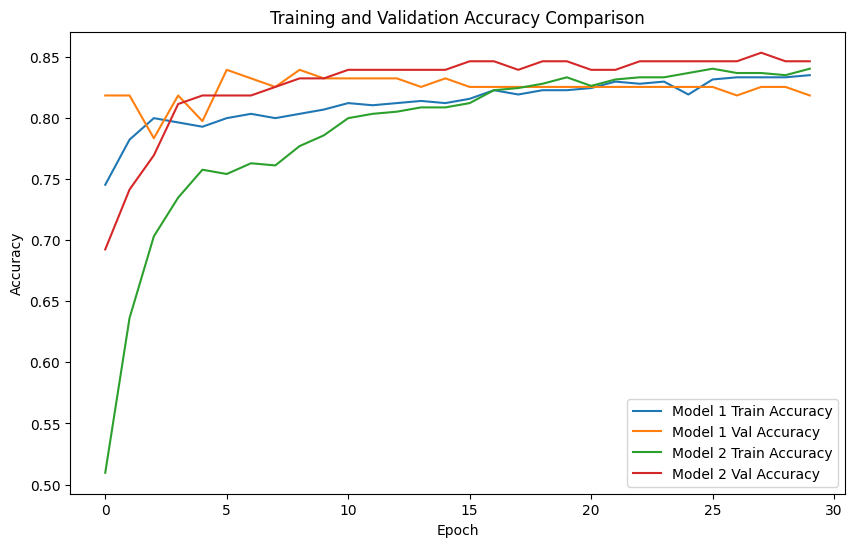

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(history1.history['accuracy'], label='Model 1 Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Model 1 Val Accuracy')

plt.plot(history2.history['accuracy'], label='Model 2 Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Model 2 Val Accuracy')

plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Compare results





**Reasoning**:
Print the test performance metrics for both models and briefly compare them.



In [ ]:
print("Model 1 Performance:")
print(f"  Test Loss: {test_loss1:.3f}")
print(f"  Test Accuracy: {test_accuracy1:.3f}")
print(f"  Test Precision: {test_precision1:.3f}")
print(f"  Test Recall: {test_recall1:.3f}")

print("\nModel 2 Performance:")
print(f"  Test Loss: {test_loss2:.3f}")
print(f"  Test Accuracy: {test_accuracy2:.3f}")
print(f"  Test Precision: {test_precision2:.3f}")
print(f"  Test Recall: {test_recall2:.3f}")

print("\nPerformance Comparison:")
if test_accuracy1 > test_accuracy2:
    print("Model 1 has slightly higher test accuracy.")
elif test_accuracy2 > test_accuracy1:
    print("Model 2 has slightly higher test accuracy.")
else:
    print("Both models have similar test accuracy.")

if test_precision1 > test_precision2:
    print("Model 1 has slightly higher test precision.")
elif test_precision2 > test_precision1:
    print("Model 2 has slightly higher test precision.")
else:
    print("Both models have similar test precision.")

if test_recall1 > test_recall2:
    print("Model 1 has slightly higher test recall.")
elif test_recall2 > test_recall1:
    print("Model 2 has slightly higher test recall.")
else:
    print("Both models have similar test recall.")

Model 1 Performance:
  Test Loss: 0.420
  Test Accuracy: 0.816
  Test Precision: 0.806
  Test Recall: 0.730

Model 2 Performance:
  Test Loss: 0.438
  Test Accuracy: 0.804
  Test Precision: 0.800
  Test Recall: 0.703

Performance Comparison:
Model 1 has slightly higher test accuracy.
Model 1 has slightly higher test precision.
Model 1 has slightly higher test recall.
